<a href="https://colab.research.google.com/github/AzaharaAED/Proyecto_ecosistema/blob/main/Proyecto__I2T_Qwen_VQA_HF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MODELO DETECCIÓN ALIMENTOS NEVERA

1. Qwen simple
2. Qwen con SAM para detectar la cantidad de cada alimentos pero ñeh
3. Qwen por cuadrículas

Using device: cuda
Image size: (175, 175)


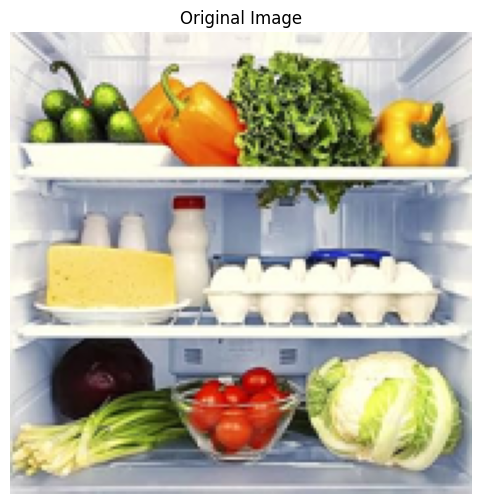

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

GLOBAL RESULT:
tomato, pepper, lettuce, egg, cheese, milk

CLEANED GLOBAL FOODS:
['tomato', 'pepper', 'lettuce', 'egg', 'cheese', 'milk']

Grid created: 6x6 = 36 cells

GRID RESULTS:
{'row': 0, 'col': 0, 'box': [0, 0, 29, 29], 'raw_result': 'not_food', 'food': None}
{'row': 0, 'col': 1, 'box': [29, 0, 58, 29], 'raw_result': 'not_food', 'food': None}
{'row': 0, 'col': 2, 'box': [58, 0, 87, 29], 'raw_result': 'not_food', 'food': None}
{'row': 0, 'col': 3, 'box': [87, 0, 116, 29], 'raw_result': 'lettuce', 'food': 'lettuce'}
{'row': 0, 'col': 4, 'box': [116, 0, 145, 29], 'raw_result': 'not_food', 'food': None}
{'row': 0, 'col': 5, 'box': [145, 0, 175, 29], 'raw_result': 'not_food', 'food': None}
{'row': 1, 'col': 0, 'box': [0, 29, 29, 58], 'raw_result': 'lettuce', 'food': 'lettuce'}
{'row': 1, 'col': 1, 'box': [29, 29, 58, 58], 'raw_result': 'tomato', 'food': 'tomato'}
{'row': 1, 'col': 2, 'box': [58, 29, 87, 58], 'raw_result': 'not_food', 'food': None}
{'row': 1, 'col': 3, 'box': [87, 29,

In [5]:
# ============================================
# GRID-BASED Qwen pipeline for food detection
# ============================================

# Si hace falta:
!pip install -q transformers accelerate sentencepiece huggingface_hub

import re
import math
import requests
import torch
import numpy as np
from io import BytesIO
from PIL import Image, ImageDraw, UnidentifiedImageError
from matplotlib import pyplot as plt

from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ============================================
# 1. Load image
# ============================================

def load_image_from_url(url, resize_half=True):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    content_type = response.headers.get("Content-Type", "")
    if "image" not in content_type.lower():
        raise ValueError(f"La URL no devolvió una imagen. Content-Type: {content_type}")

    try:
        image = Image.open(BytesIO(response.content)).convert("RGB")
    except UnidentifiedImageError:
        raise ValueError("No se pudo abrir la imagen devuelta por la URL.")

    if resize_half:
        image = image.resize((image.width // 2, image.height // 2))

    return image

url = "https://m.media-amazon.com/images/I/71cCkuKmapL._AC_UF350,350_QL80_.jpg"
image = load_image_from_url(url)
image_np = np.array(image)

print("Image size:", image.size)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

# ============================================
# 2. Load Qwen2-VL
# ============================================
qwen_model_name = "Qwen/Qwen2-VL-2B-Instruct"

qwen_processor = AutoProcessor.from_pretrained(qwen_model_name)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    qwen_model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

def ask_qwen_single_image(img, prompt, max_new_tokens=80):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text_prompt = qwen_processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = qwen_processor(
        text=[text_prompt],
        images=[img],
        padding=True,
        return_tensors="pt"
    ).to(qwen_model.device)

    with torch.no_grad():
        output_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens)

    generated_ids = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, output_ids)
    ]

    output_text = qwen_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    return output_text.strip()

# ============================================
# 3. Text cleaning helpers
# ============================================
INVALID_FOOD_NAMES = {
    "", "food", "food_name", "name_of_food", "visible food", "visible foods",
    "item", "items", "object", "objects", "ingredient", "ingredients",
    "unknown", "not_food", "none", "n/a"
}

def normalize_food_name(name):
    if name is None:
        return None

    name = name.strip().lower()
    name = re.sub(r"[^a-zA-Z\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip()

    if name in INVALID_FOOD_NAMES:
        return None

    replacements = {
        "tomatoes": "tomato",
        "cherry tomatoes": "tomato",
        "bell peppers": "pepper",
        "bell pepper": "pepper",
        "peppers": "pepper",
        "eggs": "egg",
        "cucumbers": "cucumber",
        "carrots": "carrot",
        "yogurts": "yogurt",
        "limes": "lime",
        "lettuces": "lettuce",
        "broccolis": "broccoli",
        "cheeses": "cheese",
    }

    if name in replacements:
        return replacements[name]

    if name.endswith("ies") and len(name) > 4:
        name = name[:-3] + "y"
    elif name.endswith("oes") and len(name) > 4:
        name = name[:-2]
    elif name.endswith("s") and len(name) > 3 and not name.endswith("ss"):
        name = name[:-1]

    if name in replacements:
        name = replacements[name]

    if name in INVALID_FOOD_NAMES:
        return None

    return name

def clean_global_foods(raw_text):
    parts = [x.strip() for x in raw_text.split(",") if x.strip()]
    cleaned = []
    seen = set()

    for p in parts:
        norm = normalize_food_name(p)
        if norm is None:
            continue
        if norm not in seen:
            seen.add(norm)
            cleaned.append(norm)

    return cleaned

def parse_grid_food(raw_text):
    txt = raw_text.strip().lower()

    if txt == "not_food":
        return None

    txt = txt.replace("\n", " ").strip()
    txt = txt.split(",")[0].strip()   # por si devuelve varias cosas
    txt = txt.split("-")[0].strip()   # por si mete formato raro

    return normalize_food_name(txt)

# ============================================
# 4. Global detection with full image
# ============================================
global_prompt = """
Look at the full image and identify the visible foods.

Return only a comma-separated list of UNIQUE food names.
Do not explain anything.
Do not repeat any food.
Do not include placeholders.
Do not hallucinate foods that are not clearly visible.
Maximum 12 unique foods.

Examples of valid output:
tomato, pepper, lettuce, egg, cheese, milk
"""

global_result = ask_qwen_single_image(image, global_prompt, max_new_tokens=60)
print("GLOBAL RESULT:")
print(global_result)

global_foods = clean_global_foods(global_result)
print("\nCLEANED GLOBAL FOODS:")
print(global_foods)

# ============================================
# 5. Create grid
# ============================================
GRID_ROWS = 6
GRID_COLS = 6

img_w, img_h = image.size
cell_w = img_w // GRID_COLS
cell_h = img_h // GRID_ROWS

grid_cells = []

for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        x1 = c * cell_w
        y1 = r * cell_h

        # última columna/fila recoge el resto
        x2 = (c + 1) * cell_w if c < GRID_COLS - 1 else img_w
        y2 = (r + 1) * cell_h if r < GRID_ROWS - 1 else img_h

        crop = image.crop((x1, y1, x2, y2))

        grid_cells.append({
            "row": r,
            "col": c,
            "box": [x1, y1, x2, y2],
            "crop": crop
        })

print(f"\nGrid created: {GRID_ROWS}x{GRID_COLS} = {len(grid_cells)} cells")

# ============================================
# 6. Qwen on each grid cell
# ============================================
grid_prompt = """
Identify the main visible food in this image region.

Return ONLY one food name.
Examples: tomato, pepper, lettuce, egg, cheese, milk
If there is no clear food visible, return exactly: not_food

Rules:
- Return only one food name.
- Do not explain anything.
- Do not use placeholders.
- Do not mention packaging or container type.
"""

grid_results = []

for cell in grid_cells:
    result = ask_qwen_single_image(cell["crop"], grid_prompt, max_new_tokens=8)
    food_name = parse_grid_food(result)

    grid_results.append({
        "row": cell["row"],
        "col": cell["col"],
        "box": cell["box"],
        "raw_result": result,
        "food": food_name
    })

print("\nGRID RESULTS:")
for item in grid_results:
    print(item)

# ============================================
# 7. Count foods by grid occupancy
# ============================================
food_grid_counts = {}

for item in grid_results:
    food = item["food"]
    if food is None:
        continue

    # opcional: solo contar alimentos ya vistos globalmente
    if len(global_foods) > 0 and food not in global_foods:
        continue

    if food not in food_grid_counts:
        food_grid_counts[food] = {
            "count_cells": 1,
            "boxes": [item["box"]]
        }
    else:
        food_grid_counts[food]["count_cells"] += 1
        food_grid_counts[food]["boxes"].append(item["box"])

print("\nFOOD GRID COUNTS:")
for food, stats in food_grid_counts.items():
    print(food, stats)

# ============================================
# 8. Convert cell count to quantity level
# ============================================
total_cells = GRID_ROWS * GRID_COLS

def grid_count_to_level(count_cells, total_cells):
    ratio = count_cells / total_cells

    if ratio <= 0.05:      # ~ 1-2 celdas en 4x4
        return "low"
    elif ratio <= 0.2:     # ~ 3-4 celdas
        return "medium"
    else:
        return "high"

final_food_dict = {}

# Primero metemos lo global
for food in global_foods:
    final_food_dict[food] = {
        "food": food,
        "amount_level": "unknown",
        "count_cells": 0,
        "boxes": []
    }

# Luego añadimos lo detectado por cuadrículas
for food, stats in food_grid_counts.items():
    level = grid_count_to_level(stats["count_cells"], total_cells)

    if food not in final_food_dict:
        final_food_dict[food] = {
            "food": food,
            "amount_level": level,
            "count_cells": stats["count_cells"],
            "boxes": stats["boxes"]
        }
    else:
        final_food_dict[food]["amount_level"] = level
        final_food_dict[food]["count_cells"] = stats["count_cells"]
        final_food_dict[food]["boxes"] = stats["boxes"]

final_foods = list(final_food_dict.values())

print("\nFINAL MERGED RESULTS:")
for item in final_foods:
    print(item)

# ============================================
# 9. Optional visualization of grid
# ============================================
image_draw = image.copy()
draw = ImageDraw.Draw(image_draw)

# dibujar rejilla
for c in range(1, GRID_COLS):
    x = c * cell_w
    draw.line((x, 0, x, img_h), fill="red", width=1)

for r in range(1, GRID_ROWS):
    y = r * cell_h
    draw.line((0, y, img_w, y), fill="red", width=1)

# Si queréis mostrar la imagen con rejilla, descomentad:
# plt.figure(figsize=(8, 8))
# plt.imshow(image_draw)
# plt.axis("off")
# plt.title("Grid-based analysis")
# plt.show()

# ============================================
# 10. Final plain-text output
# ============================================
print("\nPlain text final output:")
for item in final_foods:
    print(f"{item['food']} - {item['amount_level']}")

# ============================================
# 11. Extra debug
# ============================================
print("\nGrid-based quantity contribution:")
for item in final_foods:
    if item["count_cells"] > 0:
        print(f"{item['food']}: cells={item['count_cells']}, amount_level={item['amount_level']}")

Para la estimación de la cantidad de alimentos se optó por un enfoque basado en división de la imagen en cuadrículas, en lugar de utilizar un modelo de segmentación. En primer lugar, el modelo multimodal Qwen2-VL se aplicó sobre la imagen completa para obtener una lista global de alimentos visibles. En este caso, el modelo identificó los siguientes elementos: tomato, pepper, lettuce, egg, cheese y milk.

Posteriormente, la imagen se dividió en una rejilla de 6×6 cuadrículas (36 regiones). Cada una de estas regiones se analizó de forma independiente con el modelo Qwen para identificar si contenía algún alimento. A partir de estos resultados se contabilizó el número de cuadrículas en las que aparece cada alimento, lo que permite estimar de forma aproximada el espacio visual que ocupa dentro de la imagen.

Los resultados muestran que lettuce aparece en 9 cuadrículas, lo que indica una presencia elevada en la imagen y se traduce en una cantidad high. Por su parte, tomato aparece en 3 cuadrículas, clasificándose como medium, mientras que pepper y milk aparecen en una sola cuadrícula, por lo que se clasifican como low. Finalmente, aunque egg y cheese fueron detectados en la fase global, no aparecieron en ninguna cuadrícula analizada, por lo que su cantidad se mantiene como unknown.

En conjunto, este enfoque basado en cuadrículas permite estimar cantidades de forma más estable e interpretable, ya que la cantidad se calcula directamente a partir del número de regiones de la imagen donde aparece cada alimento. Esto facilita la interpretación de los resultados y evita algunos problemas asociados a los modelos de segmentación automática, como la fragmentación irregular de los objetos.

Las cantidades no funcionan muy bien, no hemos encontrado la manera de mejorarlo debido al tiempo, pero bueno es una opción que está ahí y que puede ser mejorda en el futuro.

### MODELO DETCCIÓN DE PLATOS PEPARADOS (HORNO / AIR FRIER)

En este caso usamos solo el Qwen

In [32]:
# Image
url = "https://i.ytimg.com/vi/UWD8ZJvT2gY/maxresdefault.jpg"
image = Image.open(requests.get(url, stream=True).raw)
image = image.resize((image.width // 2, image.height //2))

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {"type": "text", "text": "Create only a list of the foods visible in this image"},
        ],
    }
]

print(image)

# Preprocess the inputs
text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
# Excepted output: '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>\n<|im_start|>assistant\n'

inputs = processor(
    text=[text_prompt], images=[image], padding=True, return_tensors="pt"
)
inputs = inputs.to("cuda")

# Inference: Generation of the output
output_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids = [
    output_ids[len(input_ids) :]
    for input_ids, output_ids in zip(inputs.input_ids, output_ids)
]
output_text = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
)
print(output_text)

['- Chicken\n- Potatoes']


### MODELO PROCESADO DATOS BÁSCULA